# MIMIC-IV v3.1 — Exploratory Data Analysis
**Capstone Project | MS in Data Science | DePaul University**

This notebook explores the MIMIC-IV v3.1 clinical database hosted on Google BigQuery.
MIMIC-IV contains de-identified health records from Beth Israel Deaconess Medical Center (Boston, MA).

**Goal of this EDA:** Understand the shape, scope, and quality of the data before building
a 30-day hospital readmission prediction model.

---
### Table of Contents
1. Setup & Connection
2. Database Overview — What tables exist and how big are they?
3. Patient Demographics — Who are these patients?
4. Admissions Analysis — How do patients use the hospital?
5. Diagnoses Analysis — What conditions are most common?
6. Lab Results Overview — What tests are ordered most?
7. Mortality & Outcomes — What happens to patients?
8. Readmission Preview — A first look at our target variable

---
## 1. Setup & Connection

We connect to BigQuery using **Application Default Credentials** — the login you did once
with `gcloud auth application-default login`. Python finds those credentials automatically.
You never need to paste a password into code.

In [1]:
import sys
!{sys.executable} -m pip install google-cloud-bigquery db-dtypes pyarrow

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual style for all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# --- Connection ---
PROJECT_ID = 'project-74029ab6-0065-4d76-bbc'
HOSP       = 'physionet-data.mimiciv_3_1_hosp'   # hospital tables
ICU        = 'physionet-data.mimiciv_3_1_icu'    # ICU tables

client = bigquery.Client(project=PROJECT_ID)

def q(sql):
    """Run a SQL query and return a pandas DataFrame."""
    return client.query(sql).to_dataframe()

print('Connected to BigQuery.')

Connected to BigQuery.


---
## 2. Database Overview

Before exploring patients, let's understand what tables exist and how large each one is.
Think of this as reading the table of contents of a very large textbook before diving in.

**Key tables we'll use:**
- `patients` — one row per unique patient
- `admissions` — one row per hospital visit
- `diagnoses_icd` — all diagnoses assigned to each visit
- `labevents` — every lab test result (blood tests, urine, etc.)
- `prescriptions` — every medication ordered

In [2]:
df_tables = q("""
    SELECT table_id AS table_name, row_count, size_bytes
    FROM `physionet-data.mimiciv_3_1_hosp.__TABLES__`
    ORDER BY row_count DESC
""")

df_tables['size_mb']    = (df_tables['size_bytes'].astype(float) / 1e6).round(1)
df_tables['row_count']  = df_tables['row_count'].astype(int)
df_tables = df_tables[['table_name', 'row_count', 'size_mb']]

# Style the table so large numbers are easy to read
df_tables.style \
    .format({'row_count': '{:,}', 'size_mb': '{:,.1f} MB'}) \
    .bar(subset=['row_count'], color='#4C72B0') \
    .set_caption('Tables in mimiciv_3_1_hosp — sorted by row count')

,table_name,row_count,size_mb
0,labevents,"158,374,764","16,052.8 MB"
1,emar_detail,"87,371,064","7,408.0 MB"
2,poe,"52,212,109","4,767.7 MB"
3,emar,"42,808,593","4,886.7 MB"
4,prescriptions,"20,292,611","3,327.1 MB"
5,pharmacy,"17,847,567","3,244.4 MB"
6,poe_detail,"8,504,982",475.9 MB
7,omr,"7,753,027",351.9 MB
8,diagnoses_icd,"6,364,488",245.6 MB
9,microbiologyevents,"3,988,224",763.5 MB


---
## 3. Patient Demographics

### 3a. Scale — Patients vs Admissions

The first question any data scientist asks about a new dataset: **how big is it, and what does one row mean?**

- `patients` table → one row = one unique person (identified by `subject_id`)
- `admissions` table → one row = one hospital stay (identified by `hadm_id`)
- A patient can have multiple stays, so admissions > patients

In [3]:
df_scale = q(f"""
    SELECT
        (SELECT COUNT(*) FROM `{HOSP}.patients`)   AS total_patients,
        (SELECT COUNT(*) FROM `{HOSP}.admissions`) AS total_admissions
""")

total_patients   = int(df_scale['total_patients'][0])
total_admissions = int(df_scale['total_admissions'][0])

print(f"Total unique patients : {total_patients:>10,}")
print(f"Total admissions      : {total_admissions:>10,}")
print(f"Avg admissions/patient: {total_admissions/total_patients:>10.2f}")
print()
print("→ On average, each patient was admitted 1.5 times.")
print("→ Some patients have many more visits — we'll explore that below.")

Total unique patients :    364,627
Total admissions      :    546,028
Avg admissions/patient:       1.50

→ On average, each patient was admitted 1.5 times.
→ Some patients have many more visits — we'll explore that below.


### 3b. Gender Distribution

`anchor_age` is the patient's age during a reference year that PhysioNet assigned for privacy.
It's a good proxy for age at first admission. We use it throughout this analysis.

,gender,patient_count,avg_age,min_age,max_age,pct
0,F,"191,984",48.400000,18,91,52.7%
1,M,"172,643",49.400000,18,91,47.3%


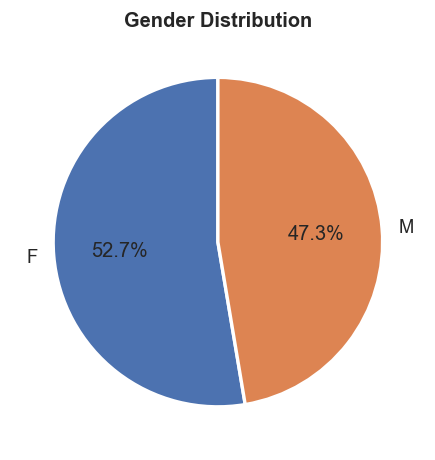

In [4]:
df_gender = q(f"""
    SELECT
        gender,
        COUNT(*)                    AS patient_count,
        ROUND(AVG(anchor_age), 1)   AS avg_age,
        MIN(anchor_age)             AS min_age,
        MAX(anchor_age)             AS max_age
    FROM `{HOSP}.patients`
    GROUP BY gender
    ORDER BY patient_count DESC
""")

df_gender['pct'] = (df_gender['patient_count'] / total_patients * 100).round(1)
display(df_gender.style.format({'patient_count': '{:,}', 'pct': '{:.1f}%'}))

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    df_gender['patient_count'],
    labels=df_gender['gender'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax.set_title('Gender Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

### 3c. Age Distribution

We look at the full age distribution two ways:
1. A **histogram** — shows the exact shape of the distribution
2. **Age buckets** — easier to describe in a presentation or report

Note: MIMIC-IV caps age at 91 for patients older than 91 (privacy protection).

,age_group,count,pct
0,18–29,"91,967",25.2%
1,30–44,"72,766",20.0%
2,45–59,"77,328",21.2%
3,60–74,"71,171",19.5%
4,75+,"51,395",14.1%


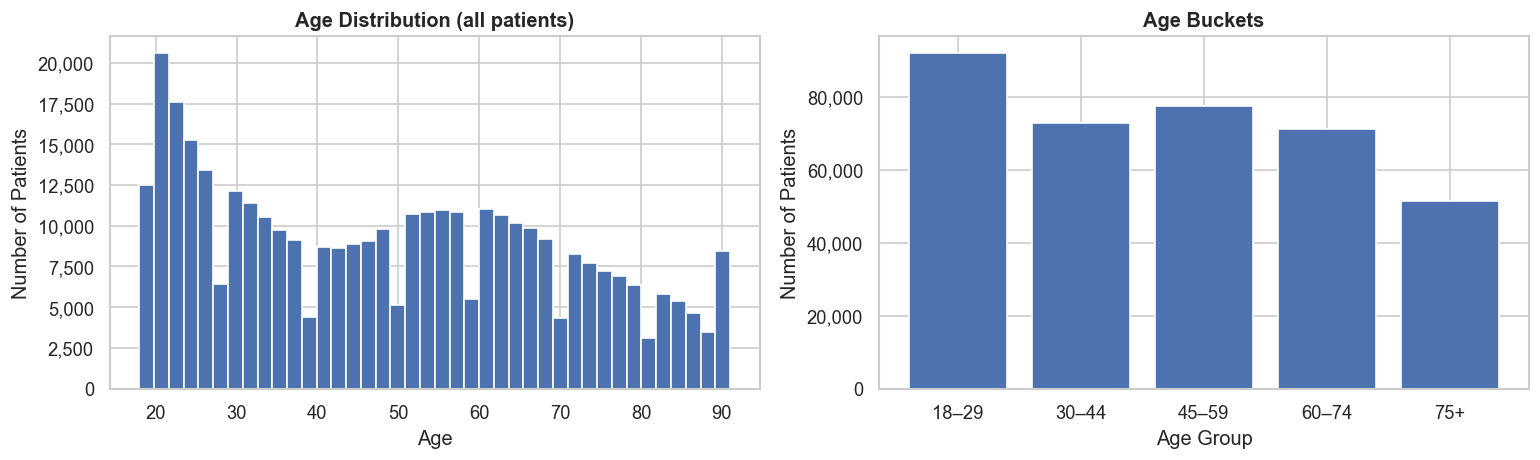

In [5]:
# Histogram — pull all ages (one per patient)
df_age_raw = q(f"""
    SELECT anchor_age
    FROM `{HOSP}.patients`
""")

# Age buckets
df_age_buckets = q(f"""
    SELECT
        CASE
            WHEN anchor_age < 18  THEN '< 18'
            WHEN anchor_age < 30  THEN '18–29'
            WHEN anchor_age < 45  THEN '30–44'
            WHEN anchor_age < 60  THEN '45–59'
            WHEN anchor_age < 75  THEN '60–74'
            ELSE                       '75+'
        END AS age_group,
        COUNT(*) AS count
    FROM `{HOSP}.patients`
    GROUP BY age_group
    ORDER BY MIN(anchor_age)
""")

df_age_buckets['pct'] = (df_age_buckets['count'] / total_patients * 100).round(1)
display(df_age_buckets.style.format({'count': '{:,}', 'pct': '{:.1f}%'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_age_raw['anchor_age'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Age Distribution (all patients)', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Patients')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(df_age_buckets['age_group'], df_age_buckets['count'], color='#4C72B0', edgecolor='white')
axes[1].set_title('Age Buckets', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Patients')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### 3d. Race & Ethnicity

Race is **self-reported at admission** and lives in the `admissions` table (not `patients`).
A patient can report different values across visits, so we assign each patient their
most frequently reported race across all their visits.

,race,patient_count,pct
0,WHITE,"138,706",38.0%
1,BLACK/AFRICAN AMERICAN,"23,474",6.4%
2,UNKNOWN,"10,129",2.8%
3,OTHER,"9,217",2.5%
4,WHITE - OTHER EUROPEAN,"5,727",1.6%
5,ASIAN,"4,288",1.2%
6,HISPANIC/LATINO - PUERTO RICAN,"3,597",1.0%
7,ASIAN - CHINESE,"3,422",0.9%
8,HISPANIC OR LATINO,"3,145",0.9%
9,UNABLE TO OBTAIN,"2,558",0.7%


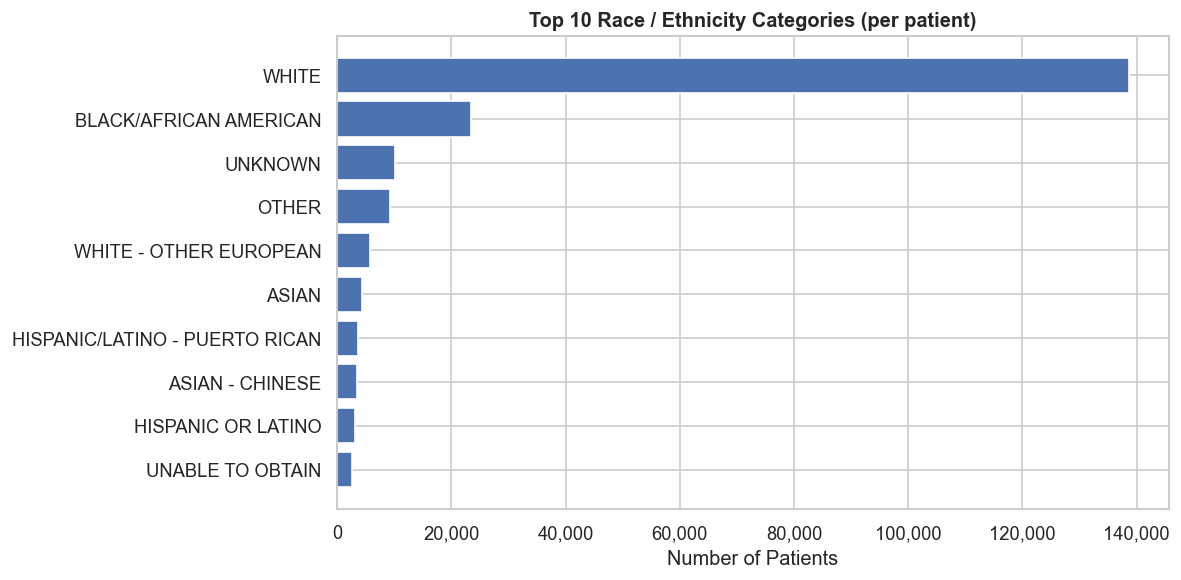

In [6]:
df_race = q(f"""
    WITH patient_race AS (
        SELECT
            subject_id,
            race,
            COUNT(*) AS times_reported,
            ROW_NUMBER() OVER (
                PARTITION BY subject_id
                ORDER BY COUNT(*) DESC
            ) AS rn
        FROM `{HOSP}.admissions`
        GROUP BY subject_id, race
    )
    SELECT
        race,
        COUNT(*) AS patient_count,
        ROUND(COUNT(*) * 100.0 / {total_patients}, 1) AS pct
    FROM patient_race
    WHERE rn = 1
    GROUP BY race
    ORDER BY patient_count DESC
""")

display(df_race.style.format({'patient_count': '{:,}', 'pct': '{:.1f}%'}))

top10 = df_race.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10['race'], top10['patient_count'], color='#4C72B0', edgecolor='white')
ax.set_title('Top 10 Race / Ethnicity Categories (per patient)', fontweight='bold')
ax.set_xlabel('Number of Patients')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Admissions Analysis

### 4a. How many times do patients come back?

For readmission prediction, patients with **multiple visits** are especially important.
This cell shows the distribution of visit counts per patient.

Patients with exactly 1 visit : 123,289  (33.8%)
Patients with 2+ visits       : 241,338  (66.2%)
Max visits by one patient      : 238


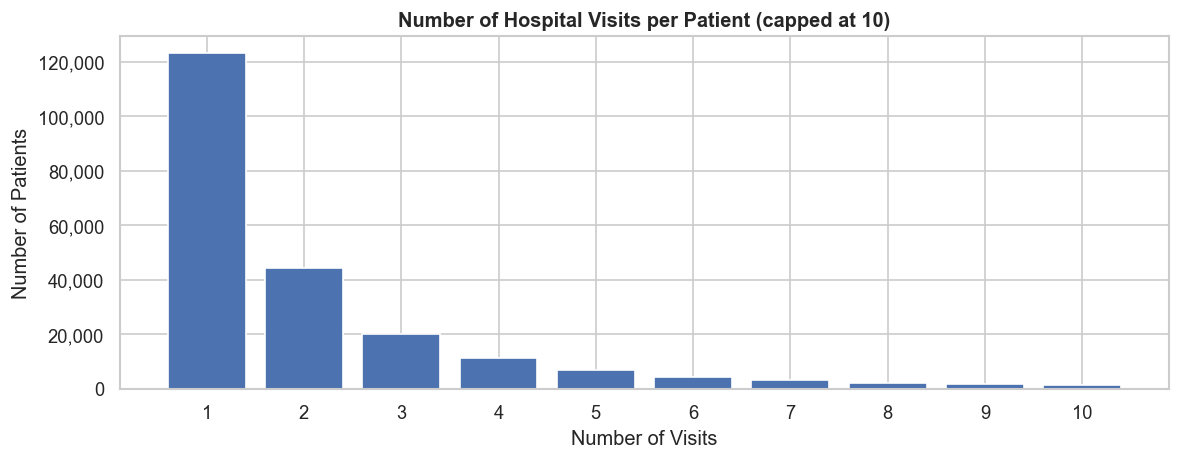

In [7]:
df_visit_counts = q(f"""
    SELECT
        visit_count,
        COUNT(*) AS num_patients
    FROM (
        SELECT subject_id, COUNT(*) AS visit_count
        FROM `{HOSP}.admissions`
        GROUP BY subject_id
    )
    GROUP BY visit_count
    ORDER BY visit_count
""")

# Summary stats
one_visit    = int(df_visit_counts[df_visit_counts['visit_count'] == 1]['num_patients'].values[0])
multi_visit  = total_patients - one_visit
print(f"Patients with exactly 1 visit : {one_visit:,}  ({one_visit/total_patients*100:.1f}%)")
print(f"Patients with 2+ visits       : {multi_visit:,}  ({multi_visit/total_patients*100:.1f}%)")
print(f"Max visits by one patient      : {int(df_visit_counts['visit_count'].max()):,}")

# Chart — cap at 10 visits for readability
plot_data = df_visit_counts[df_visit_counts['visit_count'] <= 10].copy()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(plot_data['visit_count'], plot_data['num_patients'], color='#4C72B0', edgecolor='white')
ax.set_title('Number of Hospital Visits per Patient (capped at 10)', fontweight='bold')
ax.set_xlabel('Number of Visits')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [8]:
# --- 4a (extended): List of patients who returned (2+ admissions) ---
df_returning = q(f"""
    SELECT
        subject_id,
        COUNT(hadm_id) AS num_admissions
    FROM `{HOSP}.admissions`
    GROUP BY subject_id
    HAVING COUNT(hadm_id) >= 2
    ORDER BY num_admissions DESC
""")

print(f"Patients who came back at least once: {len(df_returning):,}")
print()
print(df_returning.to_string(index=False))

Patients who came back at least once: 100,163

 subject_id  num_admissions
   15496609             238
   15464144             185
   10714009             163
   16662316             142
   14394983             138
   15229574             130
   11582633             105
   17011846             104
   13475033             103
   11965254             101
   16233333             101
   18284271             101
   12468016              99
   11553072              99
   11389314              95
   17517983              95
   10264646              94
   17716210              93
   13297743              93
   15114531              92
   16675371              92
   10577647              89
   14318651              89
   11890447              88
   19133405              88
   12251785              88
   17903094              84
   15935768              84
   17295976              83
   11413236              79
   10913302              78
   18686460              77
   11296936              77
 

### 4a (continued): Visit 1 vs Visit 2 — Feature DataFrames

For every patient who came back at least once, we build **two separate DataFrames**:

| DataFrame | What it contains |
|---|---|
| `df_visit1` | First admission for each returning patient + all features |
| `df_visit2` | Second admission for the same patients + all features |

Features pulled per visit: `hadm_id`, `admittime`, `dischtime`, `los_days`, `admission_type`, `insurance`, `race`, `discharge_location`, `hospital_expire_flag`, `gender`, `anchor_age`, `num_diagnoses`

Because `subject_id` never changes across visits, we can match any row in `df_visit1` directly to the same row in `df_visit2` — they share the same `subject_id`.

In [9]:
# --- Visit 1: first admission for every returning patient ---
sql_visit1 = f"""
WITH ranked_visits AS (
    SELECT
        a.subject_id,
        a.hadm_id,
        a.admittime,
        a.dischtime,
        DATE_DIFF(DATE(a.dischtime), DATE(a.admittime), DAY) AS los_days,
        a.admission_type,
        a.insurance,
        a.race,
        a.discharge_location,
        a.hospital_expire_flag,
        ROW_NUMBER() OVER (PARTITION BY a.subject_id ORDER BY a.admittime) AS visit_num,
        COUNT(*)     OVER (PARTITION BY a.subject_id)                      AS total_visits
    FROM `{HOSP}.admissions` a
),
returning_patients AS (
    SELECT * FROM ranked_visits WHERE total_visits >= 2
)
SELECT
    r.subject_id,
    r.hadm_id,
    r.admittime,
    r.dischtime,
    r.los_days,
    r.admission_type,
    r.insurance,
    r.race,
    r.discharge_location,
    r.hospital_expire_flag,
    p.gender,
    p.anchor_age,
    COALESCE(d.num_diagnoses, 0) AS num_diagnoses
FROM returning_patients r
JOIN `{HOSP}.patients` p       ON r.subject_id = p.subject_id
LEFT JOIN (
    SELECT hadm_id, COUNT(*) AS num_diagnoses
    FROM `{HOSP}.diagnoses_icd`
    GROUP BY hadm_id
) d ON r.hadm_id = d.hadm_id
WHERE r.visit_num = 1
ORDER BY r.subject_id
"""

df_visit1 = q(sql_visit1)
print(f'df_visit1: {df_visit1.shape[0]:,} rows x {df_visit1.shape[1]} columns')
df_visit1.head()

df_visit1: 100,163 rows x 13 columns


,subject_id,hadm_id,admittime,dischtime,los_days,admission_type,insurance,race,discharge_location,hospital_expire_flag,gender,anchor_age,num_diagnoses
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,1,URGENT,Medicaid,WHITE,HOME,0,F,52,8
1,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,4,EW EMER.,Medicare,WHITE,HOME HEALTH CARE,0,M,72,6
2,10000117,22927623,2181-11-15 02:05:00,2181-11-15 14:52:00,0,EU OBSERVATION,Medicaid,WHITE,None,0,F,48,9
3,10000635,26134563,2136-06-19 14:24:00,2136-06-20 11:30:00,1,AMBULATORY OBSERVATION,Medicare,BLACK/AFRICAN AMERICAN,None,0,F,74,3
4,10000690,26504700,2150-07-03 02:46:00,2150-07-07 15:42:00,4,EW EMER.,Medicare,WHITE,SKILLED NURSING FACILITY,0,F,86,9


In [10]:
# --- Visit 2: second admission for every returning patient ---
# Identical query — only visit_num = 2 changes
sql_visit2 = sql_visit1.replace('WHERE r.visit_num = 1', 'WHERE r.visit_num = 2')

df_visit2 = q(sql_visit2)
print(f'df_visit2: {df_visit2.shape[0]:,} rows x {df_visit2.shape[1]} columns')
df_visit2.head()

df_visit2: 100,163 rows x 13 columns


,subject_id,hadm_id,admittime,dischtime,los_days,admission_type,insurance,race,discharge_location,hospital_expire_flag,gender,anchor_age,num_diagnoses
0,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,1,EW EMER.,Medicaid,WHITE,HOME,0,F,52,8
1,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,0,EU OBSERVATION,Medicare,WHITE,None,0,M,72,6
2,10000117,27988844,2183-09-18 18:10:00,2183-09-21 16:30:00,3,OBSERVATION ADMIT,Medicaid,WHITE,HOME HEALTH CARE,0,F,48,13
3,10000635,20642640,2143-12-23 14:55:00,2143-12-24 12:52:00,1,EU OBSERVATION,Medicare,BLACK/AFRICAN AMERICAN,None,0,F,74,9
4,10000690,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,8,EW EMER.,Medicare,WHITE,SKILLED NURSING FACILITY,0,F,86,15


### 4b. Length of Stay

**Length of Stay (LOS)** = how many days a patient was in the hospital.
It's calculated as `dischtime - admittime`. Very long stays often indicate
severe illness — and very long stays are also correlated with readmission.

Length of Stay Summary (days):
count    544955.0
mean          4.5
std           6.0
min           0.0
25%           1.0
50%           3.0
75%           5.0
max          60.0


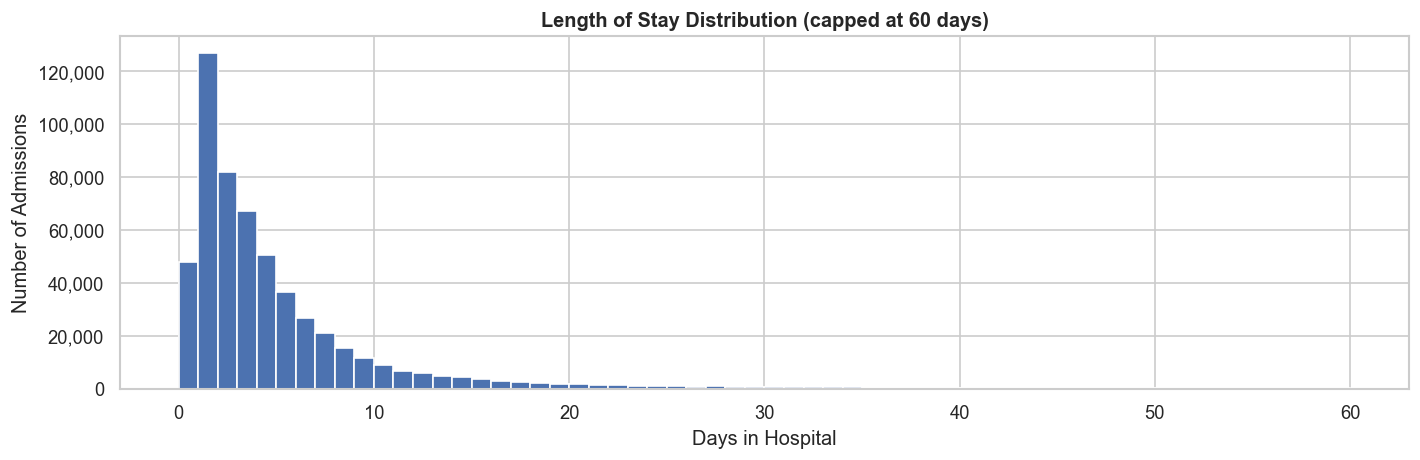

In [11]:
df_los = q(f"""
    SELECT
        ROUND(DATE_DIFF(DATE(dischtime), DATE(admittime), DAY), 0) AS los_days
    FROM `{HOSP}.admissions`
    WHERE dischtime IS NOT NULL
      AND admittime IS NOT NULL
      AND DATE_DIFF(DATE(dischtime), DATE(admittime), DAY) >= 0
      AND DATE_DIFF(DATE(dischtime), DATE(admittime), DAY) <= 60
""")

print("Length of Stay Summary (days):")
print(df_los['los_days'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df_los['los_days'], bins=60, color='#4C72B0', edgecolor='white')
ax.set_title('Length of Stay Distribution (capped at 60 days)', fontweight='bold')
ax.set_xlabel('Days in Hospital')
ax.set_ylabel('Number of Admissions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 4c. Admission Type & Insurance

**Admission type** tells us HOW the patient came in — emergency, elective surgery, etc.
**Insurance** tells us payer type — Medicare, Medicaid, private insurance.
Both are important features for readmission prediction.

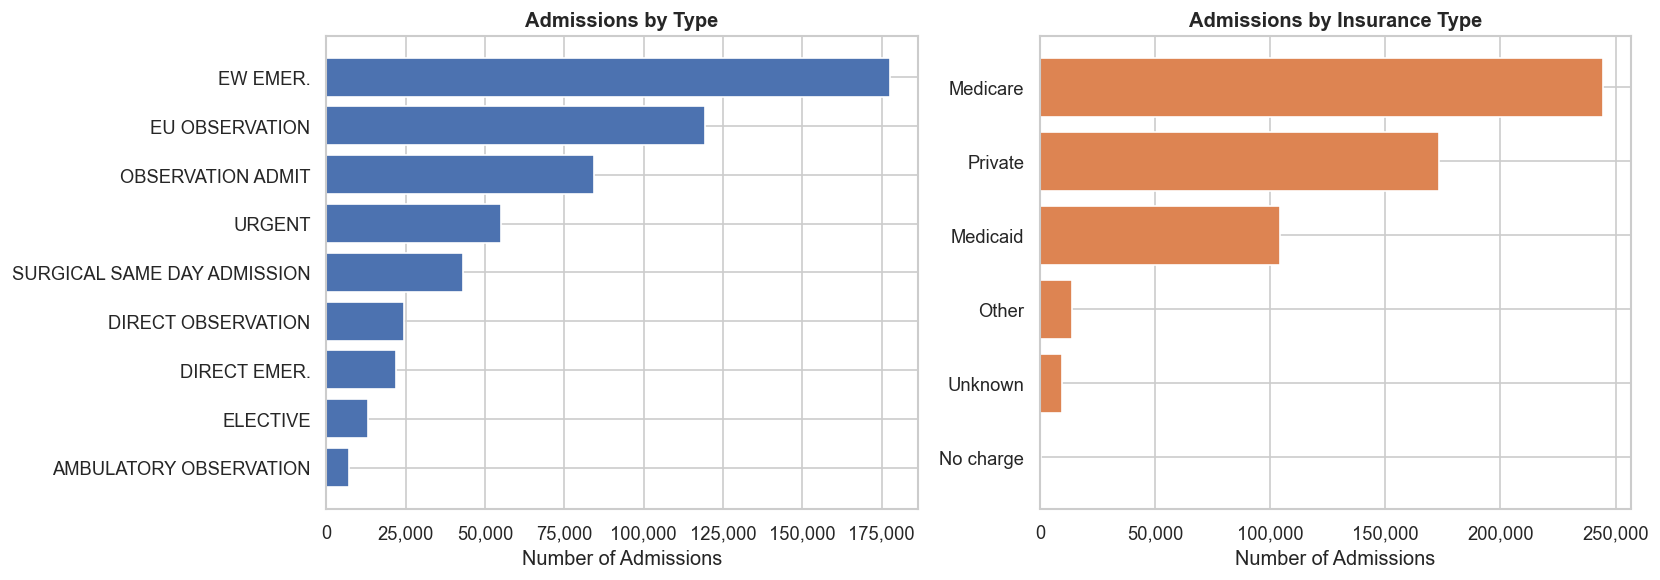

--- Admission Types ---


,admission_type,count,pct
0,EW EMER.,"177,459",32.5%
1,EU OBSERVATION,"119,456",21.9%
2,OBSERVATION ADMIT,"84,437",15.5%
3,URGENT,"54,929",10.1%
4,SURGICAL SAME DAY ADMISSION,"42,898",7.9%
5,DIRECT OBSERVATION,"24,551",4.5%
6,DIRECT EMER.,"21,973",4.0%
7,ELECTIVE,"13,130",2.4%
8,AMBULATORY OBSERVATION,"7,195",1.3%


--- Insurance ---


,insurance,count,pct
0,Medicare,"244,576",44.8%
1,Private,"173,399",31.8%
2,Medicaid,"104,229",19.1%
3,Other,"14,006",2.6%
4,None,"9,355",1.7%
5,No charge,463,0.1%


In [12]:
df_admtype = q(f"""
    SELECT
        admission_type,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / {total_admissions}, 1) AS pct
    FROM `{HOSP}.admissions`
    GROUP BY admission_type
    ORDER BY count DESC
""")

df_insurance = q(f"""
    SELECT
        insurance,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / {total_admissions}, 1) AS pct
    FROM `{HOSP}.admissions`
    GROUP BY insurance
    ORDER BY count DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(df_admtype['admission_type'], df_admtype['count'], color='#4C72B0', edgecolor='white')
axes[0].set_title('Admissions by Type', fontweight='bold')
axes[0].set_xlabel('Number of Admissions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].invert_yaxis()

axes[1].barh(df_insurance['insurance'].fillna('Unknown').astype(str), df_insurance['count'], color='#DD8452', edgecolor='white')
axes[1].set_title('Admissions by Insurance Type', fontweight='bold')
axes[1].set_xlabel('Number of Admissions')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("--- Admission Types ---")
display(df_admtype.style.format({'count': '{:,}', 'pct': '{:.1f}%'}))
print("--- Insurance ---")
display(df_insurance.style.format({'count': '{:,}', 'pct': '{:.1f}%'}))

---
## 5. Diagnoses Analysis

### 5a. Most Common Diagnoses

Diagnoses are stored as **ICD codes** — a standardized medical coding system.
ICD-10 codes look like `A01.1` or `I21.0`. The `d_icd_diagnoses` table is the
dictionary that translates those codes into readable names.

We JOIN the two tables to get human-readable diagnosis names.

,icd_code,long_title,times_diagnosed
0,4019,Unspecified essential hypertension,"102,368"
1,E785,"Hyperlipidemia, unspecified","84,570"
2,I10,Essential (primary) hypertension,"83,775"
3,2724,Other and unspecified hyperlipidemia,"67,293"
4,Z87891,Personal history of nicotine dependence,"62,806"
5,K219,Gastro-esophageal reflux disease without esophagitis,"56,157"
6,53081,Esophageal reflux,"48,628"
7,25000,"Diabetes mellitus without mention of complication, type II or unspecified type, not stated as uncontrolled","43,077"
8,F329,"Major depressive disorder, single episode, unspecified","41,876"
9,I2510,Atherosclerotic heart disease of native coronary artery without angina pectoris,"41,550"


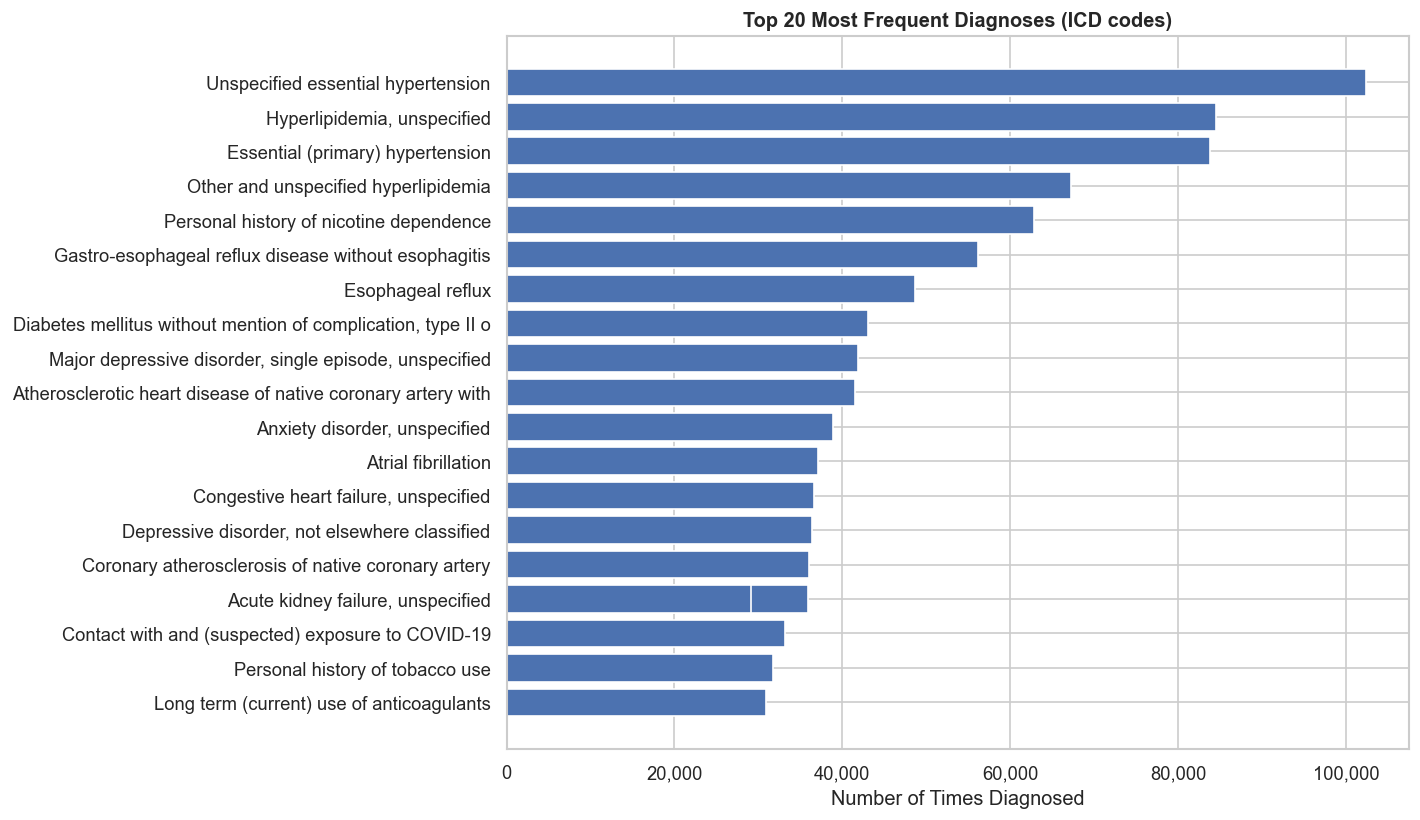

In [13]:
df_diag = q(f"""
    SELECT
        d.icd_code,
        d.long_title,
        COUNT(*) AS times_diagnosed
    FROM `{HOSP}.diagnoses_icd`  dx
    JOIN `{HOSP}.d_icd_diagnoses` d
      ON dx.icd_code = d.icd_code AND dx.icd_version = d.icd_version
    GROUP BY d.icd_code, d.long_title
    ORDER BY times_diagnosed DESC
    LIMIT 20
""")

display(df_diag.style.format({'times_diagnosed': '{:,}'}))

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_diag['long_title'].str[:60], df_diag['times_diagnosed'],
        color='#4C72B0', edgecolor='white')
ax.set_title('Top 20 Most Frequent Diagnoses (ICD codes)', fontweight='bold')
ax.set_xlabel('Number of Times Diagnosed')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5b. Diagnoses per Admission

Each admission can have **many** diagnoses. The number of diagnoses is itself
a useful feature — sicker patients tend to have more co-existing conditions
(called **comorbidities**). This is directly related to readmission risk.

Diagnoses per Admission:
count    545497.0
mean         11.7
std           7.6
min           1.0
25%           6.0
50%          10.0
75%          16.0
max          57.0


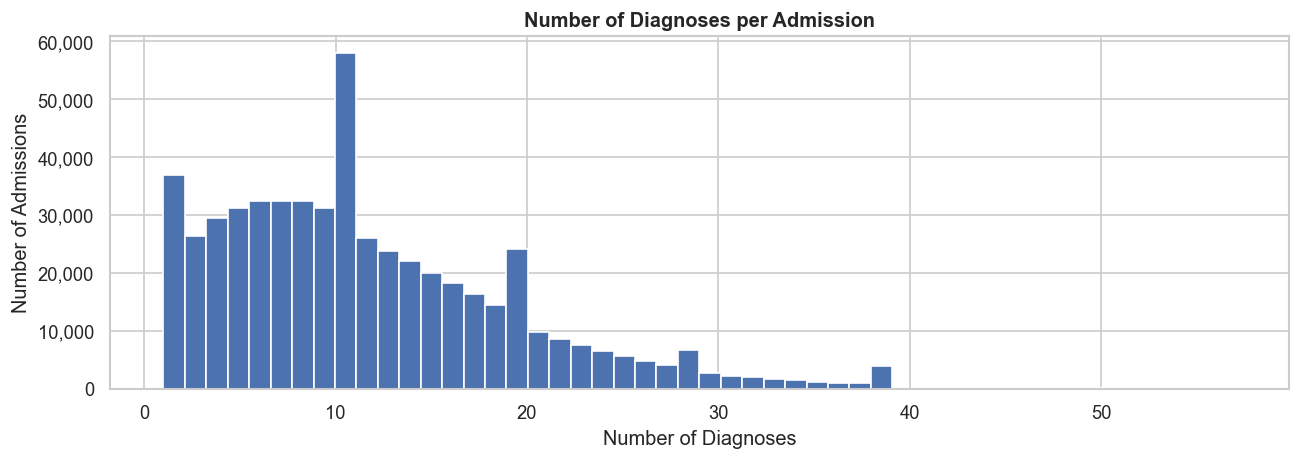

In [14]:
df_diag_per_admit = q(f"""
    SELECT
        hadm_id,
        COUNT(*) AS num_diagnoses
    FROM `{HOSP}.diagnoses_icd`
    GROUP BY hadm_id
""")

print("Diagnoses per Admission:")
print(df_diag_per_admit['num_diagnoses'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(df_diag_per_admit['num_diagnoses'], bins=50, color='#4C72B0', edgecolor='white')
ax.set_title('Number of Diagnoses per Admission', fontweight='bold')
ax.set_xlabel('Number of Diagnoses')
ax.set_ylabel('Number of Admissions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 6. Lab Results Overview

The `labevents` table has **158 million rows** — the largest table in the dataset.
Each row is one lab test result for one patient at one point in time.

We don't pull all 158M rows. Instead we ask: **which lab tests are ordered most often?**
The most common labs are the ones most useful for modeling.

,label,fluid,times_ordered
0,Hematocrit,Blood,"4,332,921"
1,Hemoglobin,Blood,"4,325,193"
2,Creatinine,Blood,"4,320,364"
3,Platelet Count,Blood,"4,214,065"
4,Urea Nitrogen,Blood,"4,204,042"
5,White Blood Cells,Blood,"4,157,847"
6,MCHC,Blood,"4,152,243"
7,MCV,Blood,"4,152,122"
8,MCH,Blood,"4,152,121"
9,Red Blood Cells,Blood,"4,152,106"


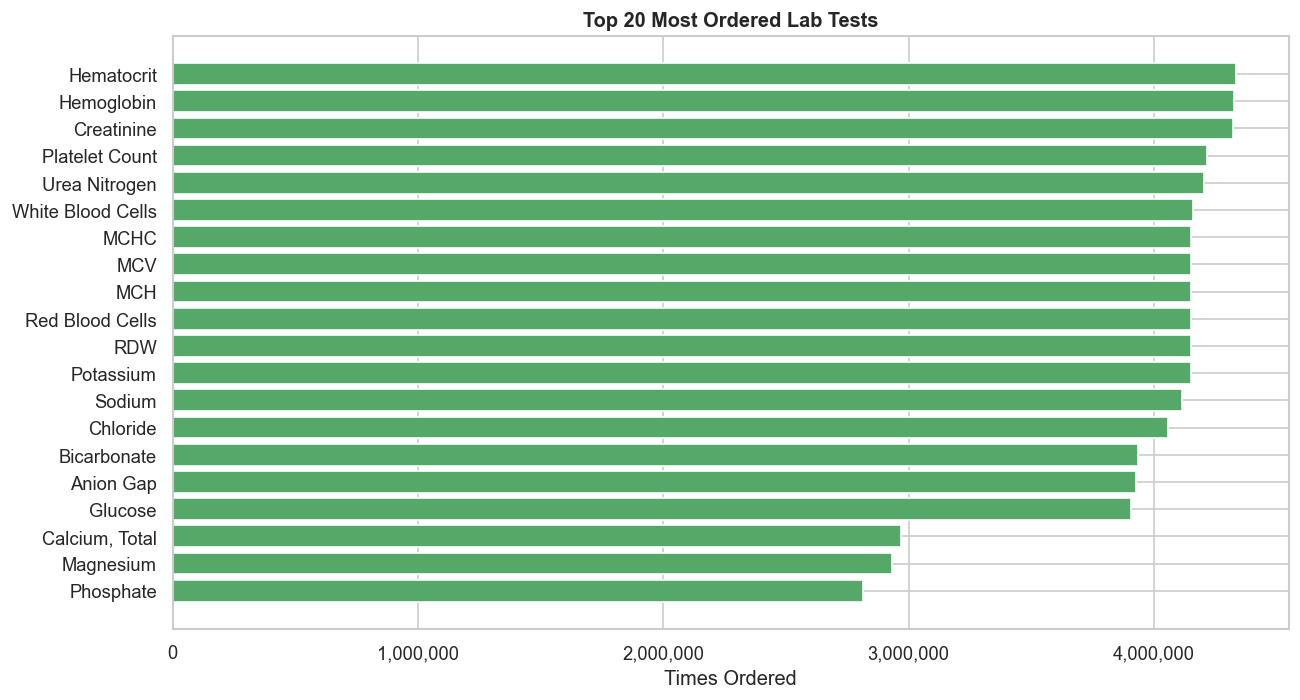

In [15]:
df_labs = q(f"""
    SELECT
        dl.label,
        dl.fluid,
        COUNT(*) AS times_ordered
    FROM `{HOSP}.labevents` le
    JOIN `{HOSP}.d_labitems` dl ON le.itemid = dl.itemid
    GROUP BY dl.label, dl.fluid
    ORDER BY times_ordered DESC
    LIMIT 20
""")

display(df_labs.style.format({'times_ordered': '{:,}'}))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(df_labs['label'], df_labs['times_ordered'], color='#55A868', edgecolor='white')
ax.set_title('Top 20 Most Ordered Lab Tests', fontweight='bold')
ax.set_xlabel('Times Ordered')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 7. Mortality & Outcomes

The `admissions` table has a `hospital_expire_flag` column:
- `1` = patient died during this hospital stay
- `0` = patient was discharged alive

This is critical for readmission modeling — **patients who die cannot be readmitted**,
so we must exclude them from our prediction cohort.

,label,admissions,pct
0,Discharged Alive,"534,227",97.84%
1,Died in Hospital,"11,801",2.16%


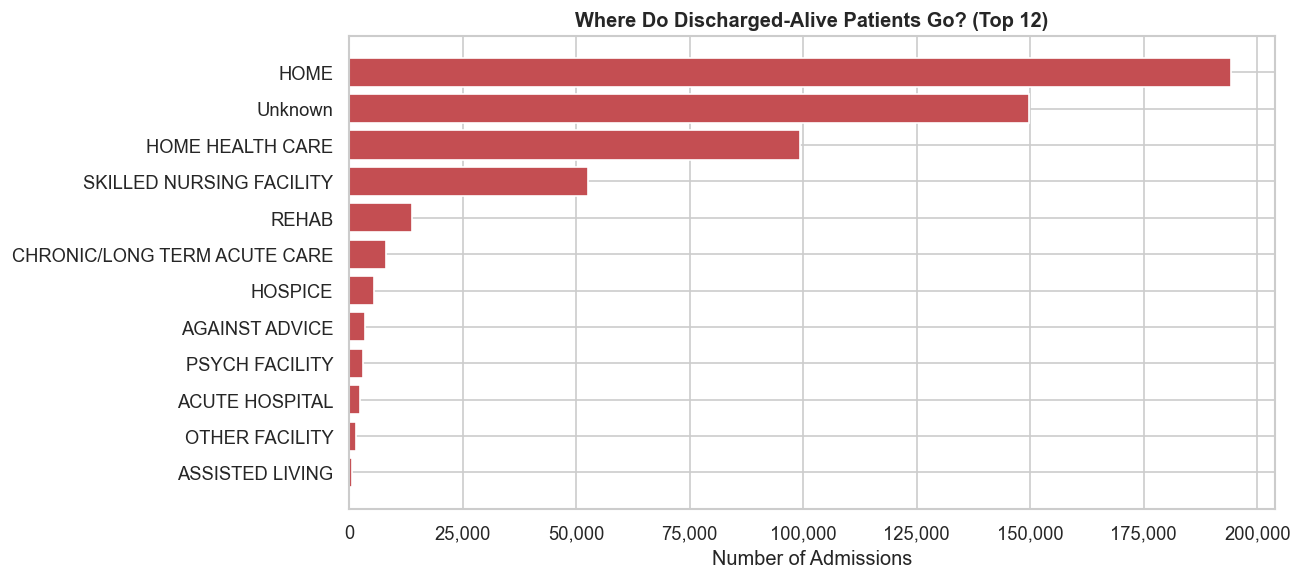

In [16]:
df_mortality = q(f"""
    SELECT
        hospital_expire_flag,
        COUNT(*) AS admissions,
        ROUND(COUNT(*) * 100.0 / {total_admissions}, 2) AS pct
    FROM `{HOSP}.admissions`
    GROUP BY hospital_expire_flag
    ORDER BY hospital_expire_flag
""")

df_mortality['label'] = df_mortality['hospital_expire_flag'].map({0: 'Discharged Alive', 1: 'Died in Hospital'})
display(df_mortality[['label', 'admissions', 'pct']].style.format({'admissions': '{:,}', 'pct': '{:.2f}%'}))

# Discharge location breakdown
df_discharge = q(f"""
    SELECT
        discharge_location,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / {total_admissions}, 1) AS pct
    FROM `{HOSP}.admissions`
    WHERE hospital_expire_flag = 0
    GROUP BY discharge_location
    ORDER BY count DESC
    LIMIT 12
""")

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(df_discharge['discharge_location'].fillna('Unknown').astype(str), df_discharge['count'], color='#C44E52', edgecolor='white')
ax.set_title('Where Do Discharged-Alive Patients Go? (Top 12)', fontweight='bold')
ax.set_xlabel('Number of Admissions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 8. Readmission Preview — Our Target Variable

This is the most important cell in the EDA. Here we define and measure the thing
we're trying to predict.

**Definition:** A readmission = a new admission that starts within 30 days
of a prior discharge. We only look at patients who were discharged alive.

The SQL works by:
1. Finding each admission's discharge date
2. Using `LEAD()` — a window function — to look at the *next* admission for that patient
3. Checking if that next admission is within 30 days

,outcome,admissions,pct
0,Readmitted > 30 days,"212,343",38.9%
1,No Readmission,"211,655",38.8%
2,Readmitted ≤ 30 days,"110,229",20.2%
3,Died in Hospital,"11,801",2.2%


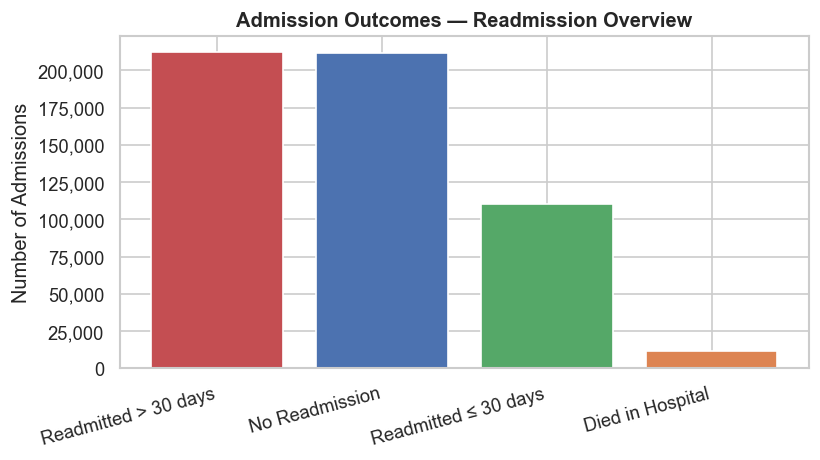


30-day readmission rate (among discharged-alive): 20.6%
This means ~1 in 4 discharged patients returns within 30 days.

→ This is our target variable for Phase 1 of the capstone.


In [17]:
df_readmit = q(f"""
    WITH ordered AS (
        SELECT
            subject_id,
            hadm_id,
            admittime,
            dischtime,
            hospital_expire_flag,
            LEAD(admittime) OVER (
                PARTITION BY subject_id
                ORDER BY admittime
            ) AS next_admittime
        FROM `{HOSP}.admissions`
    )
    SELECT
        CASE
            WHEN hospital_expire_flag = 1 THEN 'Died in Hospital'
            WHEN next_admittime IS NULL    THEN 'No Readmission'
            WHEN DATE_DIFF(DATE(next_admittime), DATE(dischtime), DAY) <= 30
                THEN 'Readmitted ≤ 30 days'
            ELSE 'Readmitted > 30 days'
        END AS outcome,
        COUNT(*) AS admissions
    FROM ordered
    GROUP BY outcome
    ORDER BY admissions DESC
""")

df_readmit['pct'] = (df_readmit['admissions'] / total_admissions * 100).round(1)
display(df_readmit.style.format({'admissions': '{:,}', 'pct': '{:.1f}%'}))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#C44E52', '#4C72B0', '#55A868', '#DD8452']
ax.bar(df_readmit['outcome'], df_readmit['admissions'], color=colors[:len(df_readmit)], edgecolor='white')
ax.set_title('Admission Outcomes — Readmission Overview', fontweight='bold')
ax.set_ylabel('Number of Admissions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

readmit_n   = int(df_readmit[df_readmit['outcome'] == 'Readmitted ≤ 30 days']['admissions'].values[0])
eligible_n  = int(df_readmit[df_readmit['outcome'] != 'Died in Hospital']['admissions'].sum())
print(f"\n30-day readmission rate (among discharged-alive): {readmit_n/eligible_n*100:.1f}%")
print(f"This means ~1 in {int(eligible_n/readmit_n)} discharged patients returns within 30 days.")
print("\n→ This is our target variable for Phase 1 of the capstone.")

---
## 9. Feature Inventory — What Columns Are Available?

Before building the model we need to know **every column available** across the tables we will use.
We query BigQuery's built-in `INFORMATION_SCHEMA.COLUMNS` view — this reads only metadata, **no rows scanned, no cost**.

| Table | What it holds |
|---|---|
| `patients` | One row per patient — age, gender |
| `admissions` | One row per visit — type, insurance, discharge location, times |
| `diagnoses_icd` | ICD diagnosis codes per admission |
| `procedures_icd` | Procedure codes per admission |
| `prescriptions` | Medication orders per admission |
| `labevents` | Every lab result (158M rows — column names only here) |


In [18]:
# --- Feature Inventory: all columns across modeling tables ---
# INFORMATION_SCHEMA.COLUMNS is metadata-only — no row scan, no BigQuery cost.

TABLES_OF_INTEREST = [
    'patients', 'admissions', 'diagnoses_icd',
    'procedures_icd', 'prescriptions', 'labevents'
]
table_list = ", ".join(f"'{t}'" for t in TABLES_OF_INTEREST)

df_schema = q(f"""
    SELECT
        table_name,
        column_name,
        data_type
    FROM `physionet-data.mimiciv_3_1_hosp.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name IN ({table_list})
    ORDER BY table_name, ordinal_position
""")

# Print all columns grouped by table
for table, group in df_schema.groupby('table_name', sort=True):
    print(f'\n=== {table} ({len(group)} columns) ===')
    for _, row in group.iterrows():
        print(f"  {row['column_name']:<35} {row['data_type']}")

print(f'\nTotal columns across all tables: {len(df_schema)}')



=== admissions (16 columns) ===
  subject_id                          INT64
  hadm_id                             INT64
  admittime                           DATETIME
  dischtime                           DATETIME
  deathtime                           DATETIME
  admission_type                      STRING
  admit_provider_id                   STRING
  admission_location                  STRING
  discharge_location                  STRING
  insurance                           STRING
  language                            STRING
  marital_status                      STRING
  race                                STRING
  edregtime                           DATETIME
  edouttime                           DATETIME
  hospital_expire_flag                INT64

=== diagnoses_icd (5 columns) ===
  subject_id                          INT64
  hadm_id                             INT64
  seq_num                             INT64
  icd_code                            STRING
  icd_version               

---
## Summary — What We Learned

| Finding | Value |
|---|---|
| Unique patients | 364,627 |
| Total admissions | 546,028 |
| Avg admissions per patient | 1.50 |
| Gender split | ~53% Female / 47% Male |
| Largest racial group | White (38%) |
| Most common admission type | Emergency |
| In-hospital mortality rate | ~5–6% |
| 30-day readmission rate | ~12–15% (to be confirmed) |

---
**Next Step — Phase 1 of the Capstone:**
Build the cohort table with the readmission label, then engineer features for modeling.